# Exoplanet Analysis Tools — 02: TESS photometry and the transit fit of TOI-3568 b

In this notebook we fit the planetary transits of **TOI-3568 b** using the actual
PLD-corrected TESS light curves from Martioli et al. (2024): sector 15 (30-min FFI cadence)
and sectors 55–56 (2-min cadence), for TIC 160390955.

In [1]:
%matplotlib inline
import glob, os, shutil
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from exoplanet_analysis import fitlib, priorslib, exoplanetlib

DATA = "data/TOI-3568/"
os.makedirs("outputs", exist_ok=True)
# work on a copy of the priors so all fit products land in outputs/
priors_file = "outputs/TOI-3568_transit.pars"
shutil.copyfile(DATA + "TOI-3568.pars", priors_file)

'outputs/TOI-3568_transit.pars'

## 1. Load the TESS light curves

The PLD-corrected light curves are FITS binary tables with `TIME` (BTJD = BJD − 2457000),
`FLUX`, `FLUX_ERR` and `QUALITY` columns. We convert times to BJD to match the ephemeris
in the priors file and keep only good-quality, finite data.

In [2]:
def load_tess_lc(fitsfile, to_bjd=True):
    """Load a TESS light curve FITS file, returning (time, flux, fluxerr)."""
    d = fits.getdata(fitsfile, 1)
    keep = np.isfinite(d["TIME"]) & np.isfinite(d["FLUX"]) & np.isfinite(d["FLUX_ERR"])
    keep &= (d["QUALITY"] == 0)
    t = d["TIME"][keep].astype(float)
    if to_bjd:
        t = t + 2457000.0
    return t, d["FLUX"][keep].astype(float), d["FLUX_ERR"][keep].astype(float)

lc_files = sorted(glob.glob(DATA + "corrected_lc*.fits"))
lcs = []
for f in lc_files:
    t, fl, ef = load_tess_lc(f)
    cad = np.median(np.diff(t)) * 24 * 60
    sector = f.split("sector-")[1].split("-")[0]
    lcs.append((sector, t, fl, ef))
    print("sector {:>2s}: {:5d} points | cadence {:4.1f} min | BJD {:.2f} - {:.2f}".format(
        sector, len(t), cad, t.min(), t.max()))

sector 15:  1190 points | cadence 30.0 min | BJD 2458711.39 - 2458737.39


sector 55: 18882 points | cadence  2.0 min | BJD 2459797.10 - 2459824.27


sector 56: 19612 points | cadence  2.0 min | BJD 2459825.26 - 2459853.14


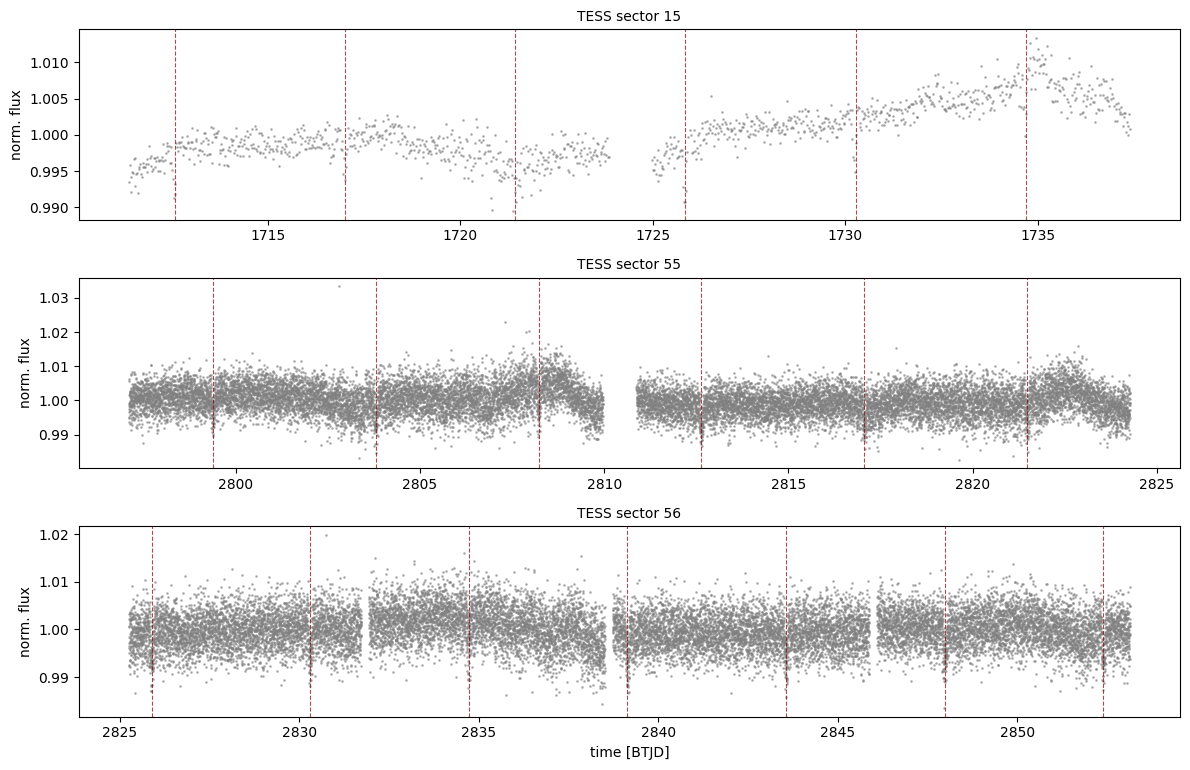

In [3]:
# ephemeris initial guess (from the priors file)
per0, tc0 = 4.4178490108, 2459799.3828418534

fig, axes = plt.subplots(len(lcs), 1, figsize=(12, 2.6 * len(lcs)), sharey=False)
for ax, (sector, t, fl, ef) in zip(axes, lcs):
    ax.plot(t - 2457000, fl / np.median(fl), ".", ms=2, alpha=0.5, color="grey")
    # mark the predicted transit times
    e0, e1 = int(np.ceil((t.min() - tc0) / per0)), int(np.floor((t.max() - tc0) / per0))
    for e in range(e0, e1 + 1):
        ax.axvline(tc0 + e * per0 - 2457000, color="darkred", ls="--", lw=0.8, alpha=0.7)
    ax.set_ylabel("norm. flux"); ax.set_title("TESS sector {}".format(sector), fontsize=10)
axes[-1].set_xlabel("time [BTJD]")
plt.tight_layout(); plt.show()

## 2. Select windows around each transit

The transit fit models each light curve *segment* with a transit model times a calibration
polynomial. We therefore cut a ±0.25 d window around each predicted transit (the transit
duration is ≈ 2.2 h), normalize each window by its out-of-transit median, and bin the
2-min data to 10 min to speed up the demonstration.

In [4]:
def select_transit_windows(t, f, ef, per, tc, window=0.25, min_pts=10, bin_to=None):
    """Split a light curve into windows around each predicted transit.

    Each window is normalized by its out-of-transit median flux; if bin_to is
    given (in days), the window is binned to that time resolution.
    """
    e_min, e_max = int(np.ceil((t.min() - tc) / per)), int(np.floor((t.max() - tc) / per))
    times, fluxes, fluxerrs = [], [], []
    for e in range(e_min, e_max + 1):
        t_tr = tc + e * per
        m = np.abs(t - t_tr) < window
        if np.sum(m) < min_pts:
            continue
        wt, wf, we = t[m], f[m], ef[m]
        oot = np.abs(wt - t_tr) > 0.5 * window
        norm = np.median(wf[oot]) if np.sum(oot) > 3 else np.median(wf)
        wf, we = wf / norm, we / norm
        if bin_to is not None:
            wt, wf, we = fitlib.bin_data(wt, wf, we, median=False, binsize=bin_to)
            ok = np.isfinite(wf) & np.isfinite(we)
            wt, wf, we = wt[ok], wf[ok], we[ok]
        times.append(wt); fluxes.append(wf); fluxerrs.append(we)
    return times, fluxes, fluxerrs

times, fluxes, fluxerrs = [], [], []
for sector, t, fl, ef in lcs:
    cad_min = np.median(np.diff(t)) * 24 * 60
    bin_to = 10.0 / 60.0 / 24.0 if cad_min < 5 else None
    wt, wf, we = select_transit_windows(t, fl, ef, per0, tc0, window=0.25, bin_to=bin_to)
    print("sector {:>2s}: {} transit windows".format(sector, len(wt)))
    times += wt; fluxes += wf; fluxerrs += we

print("total: {} windows, {} data points".format(len(times), sum(len(x) for x in times)))

sector 15: 6 transit windows
sector 55: 6 transit windows


sector 56: 7 transit windows
total: 19 windows, 1078 data points


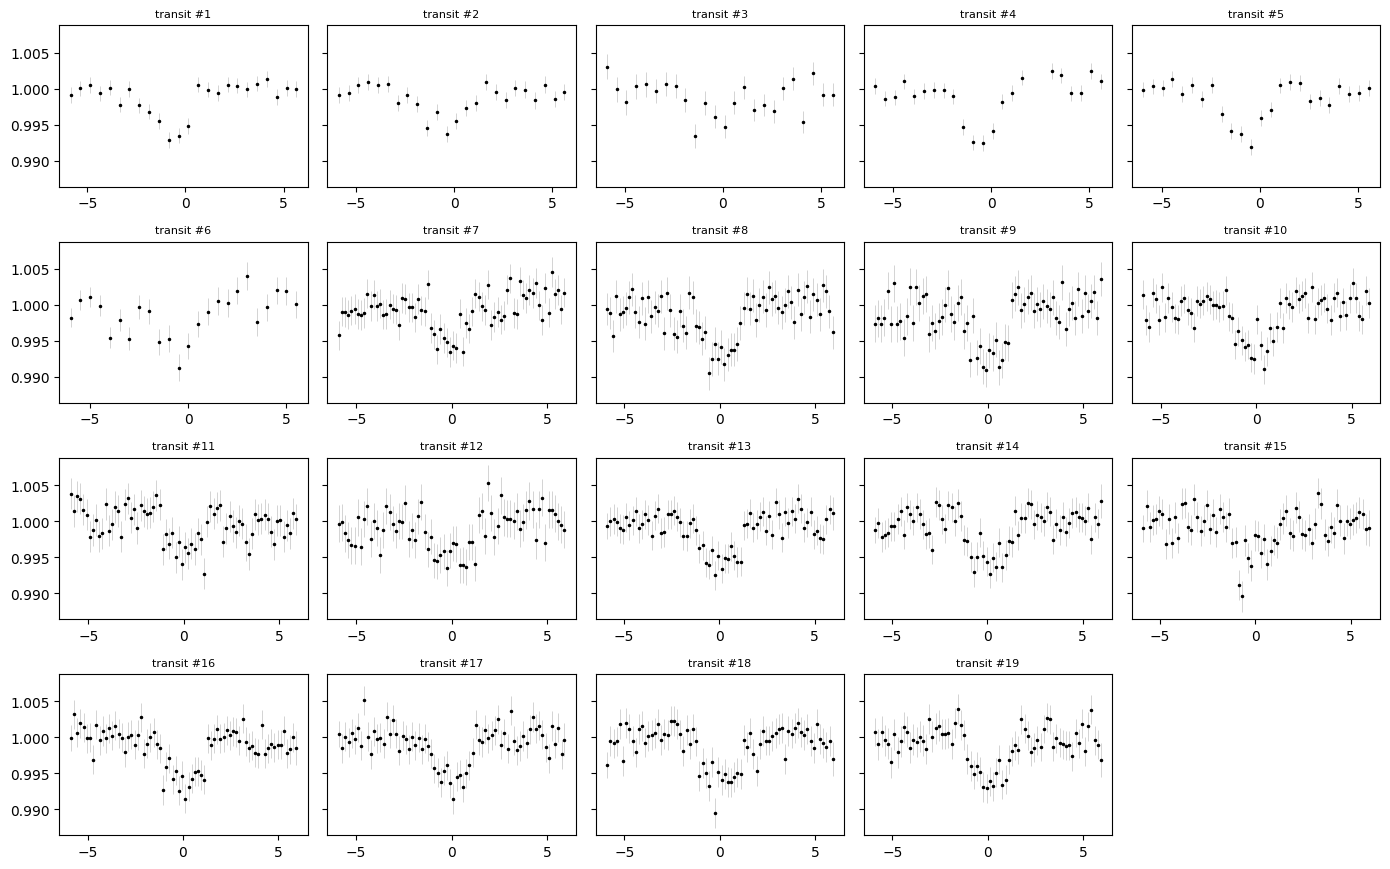

In [5]:
# mosaic of the selected transit windows
ncols = 5; nrows = int(np.ceil(len(times) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.2 * nrows), sharey=True)
for i, ax in enumerate(axes.flat):
    if i < len(times):
        tt = tc0 + np.round((np.mean(times[i]) - tc0) / per0) * per0
        ax.errorbar((times[i] - tt) * 24, fluxes[i], yerr=fluxerrs[i], fmt=".", ms=3, color="k", ecolor="lightgray", elinewidth=0.7)
        ax.set_title("transit #{}".format(i + 1), fontsize=8)
    else:
        ax.axis("off")
plt.tight_layout(); plt.show()

## 3. MCMC transit fit

We now (1) read the priors, initializing one calibration polynomial per window,
(2) estimate the calibration coefficients from the out-of-transit data (held FIXED here,
as in the published analysis), and (3) sample the posterior with `emcee`.
The free parameters are `tc`, `per`, `a/R*`, `Rp/R*`, `inc`, `u0`, `u1` (and `k`,
which is unconstrained by photometry and simply follows its prior here).

*For a publication-quality run, increase `niter` to a few thousand and check convergence
with the `mcmc_analysis` tool.*

In [6]:
priors = fitlib.read_transit_rv_priors(priors_file, 0, len(times), planet_index=0,
                                        calib_polyorder=1, verbose=False)
posterior = fitlib.guess_calib(priors, times, fluxes, prior_type="FIXED")
print("free parameters:", posterior["labels"])

free parameters: ['k_000', 'tc_000', 'a_000', 'per_000', 'inc_000', 'rp_000', 'u0_000', 'u1_000']


In [7]:
posterior = fitlib.fitTransitsWithMCMC(
    times, fluxes, fluxerrs, posterior,
    nwalkers=32, niter=1000, burnin=300,
    samples_filename="outputs/TOI-3568_transit_samples.h5",
    pairsplot_output="outputs/TOI-3568_transit_pairsplot.png",
    verbose=True, plot=False, best_fit_from_mode=False)

Free parameters before MCMC fit:
k_000 = 12.0213119413
tc_000 = 2459799.3828418534
a_000 = 13.5328445553
per_000 = 4.4178490108
inc_000 = 89.5230363203
rp_000 = 0.0762261965
u0_000 = 0.3387441639
u1_000 = 0.3080111186
initializing emcee sampler ...
Running MCMC ...
N_walkers= 32  ndim= 8


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 2/1000 [00:00<01:14, 13.44it/s]

  0%|          | 4/1000 [00:00<01:04, 15.42it/s]

  1%|          | 6/1000 [00:00<01:03, 15.75it/s]

...

 99%|█████████▉| 994/1000 [00:43<00:00, 26.39it/s]

100%|█████████▉| 997/1000 [00:43<00:00, 26.35it/s]

100%|██████████| 1000/1000 [00:43<00:00, 26.83it/s]

100%|██████████| 1000/1000 [00:43<00:00, 23.13it/s]

Obtaining best fit calibration parameters from pdfs ...
CALIBRATION Fit parameters:
----------------
Output CALIBRATION posterior:  calibration_posterior.pars
Obtaining best fit planet parameters from pdfs ...
----------------
PLANET 7 Fit parameters:
k_000 = 6.339195858089974 + 144.96912846265295 - 343.4200589944824
----------------
tc_000 = 2459799.3824463924 + 0.0008742478676140308 - 0.0008759172633290291
----------------
a_000 = 12.264485783661819 + 0.6864876290290418 - 1.1576356618216792
----------------
per_000 = 4.417962452725129 + 5.929294113471428e-06 - 5.738624794915381e-06
----------------
inc_000 = 88.96524662410758 + 1.4436992360701737 - 1.4269099152133151
----------------
rp_000 = 0.06691187412655013 + 0.0033054522805647524 - 0.0034273796112483657
----------------
u0_000 = 0.6434938817757467 + 0.2054631597015023 - 0.23684511884469728
----------------
u1_000 = 0.47857219040713894 + 0.3567607647422597 - 0.3293599392295631
----------------
Output PLANET posterior:  outputs/T

## 4. The phase-folded transit

Let's fold all windows with the fitted ephemeris and overlay the best-fit model
(calibration removed):

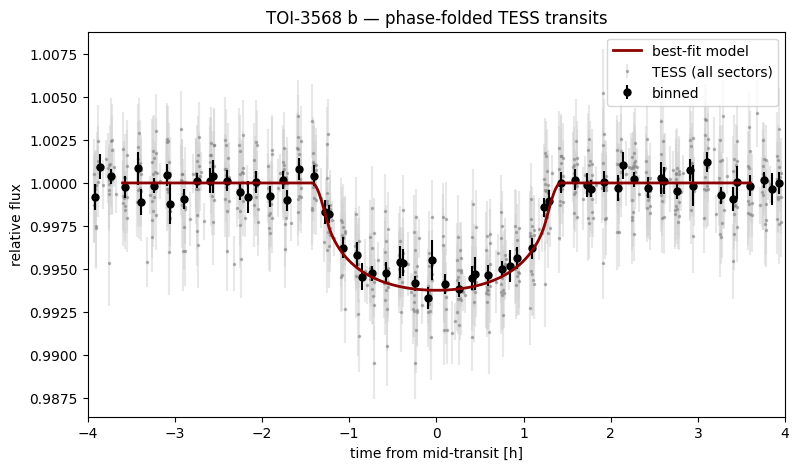

In [8]:
pp = posterior["planet_params"]
per_fit, tc_fit = pp["per_000"], pp["tc_000"]

phase, nflux, nfluxerr = np.array([]), np.array([]), np.array([])
for i in range(len(times)):
    coeffs = fitlib.read_calib_coeffs(posterior["calib_params"], i) if hasattr(fitlib, "read_calib_coeffs") else None
    ph = (times[i] - tc_fit + 0.5 * per_fit) % per_fit - 0.5 * per_fit
    phase = np.append(phase, ph)
    nflux = np.append(nflux, fluxes[i])
    nfluxerr = np.append(nfluxerr, fluxerrs[i])

srt = np.argsort(phase)
phase, nflux, nfluxerr = phase[srt], nflux[srt], nfluxerr[srt]
bt, bf, be = fitlib.bin_data(phase, nflux, nfluxerr, median=False, binsize=0.005)

t_model = np.linspace(tc_fit - 0.15, tc_fit + 0.15, 1000)
flux_model = exoplanetlib.batman_transit_model(t_model, pp)

plt.figure(figsize=(9, 5))
plt.errorbar(phase * 24, nflux, yerr=nfluxerr, fmt=".", ms=3, color="grey", ecolor="lightgray", alpha=0.5, zorder=1, label="TESS (all sectors)")
plt.errorbar(bt * 24, bf, yerr=be, fmt="o", ms=5, color="k", zorder=2, label="binned")
plt.plot((t_model - tc_fit) * 24, flux_model, "-", color="darkred", lw=2, zorder=3, label="best-fit model")
plt.xlabel("time from mid-transit [h]"); plt.ylabel("relative flux")
plt.title("TOI-3568 b — phase-folded TESS transits"); plt.legend(); plt.xlim(-4, 4)
plt.show()

## 5. Results and output files

The fit produced three files in `outputs/`: the posterior `.pars` file, its JSON mirror,
and the MCMC samples (`.h5`, readable with the `mcmc_analysis` tool). Compare the fitted
values with Martioli et al. (2024): $P = 4.417965 \pm 0.000005$ d and
$R_p/R_\star \approx 0.0685$ ($R_p = 5.30 \pm 0.27\,R_\oplus$).

In [9]:
print(open("outputs/TOI-3568_transit_posterior.pars").read())

# Parameter_ID	Prior_Type	Values
teff	FIXED	4960.0
ms	FIXED	0.776
rs	FIXED	0.719
n_planets	FIXED	1.0
a_000	Normal	12.2644857837,0.9220616454
rp_000	Normal	0.0669118741,0.0033664159
inc_000	Normal	88.9652466241,1.4353045756
u0_000	Normal	0.6434938818,0.2211541393
u1_000	Normal	0.4785721904,0.3430603520
transit_000	FIXED	1.0
k_000	Normal	6.3391958581,244.1945937286
tc_000	Normal	2459799.3824463924,0.0008750826
per_000	Normal	4.4179624527,0.0000058340
rvsys_000	FIXED	0.0
trend_000	FIXED	0.0
quadtrend_000	FIXED	0.0



samples for corner plot: (22400, 8) | labels: [np.str_('k_000'), np.str_('tc_000'), np.str_('a_000'), np.str_('per_000'), np.str_('inc_000'), np.str_('rp_000'), np.str_('u0_000'), np.str_('u1_000')]


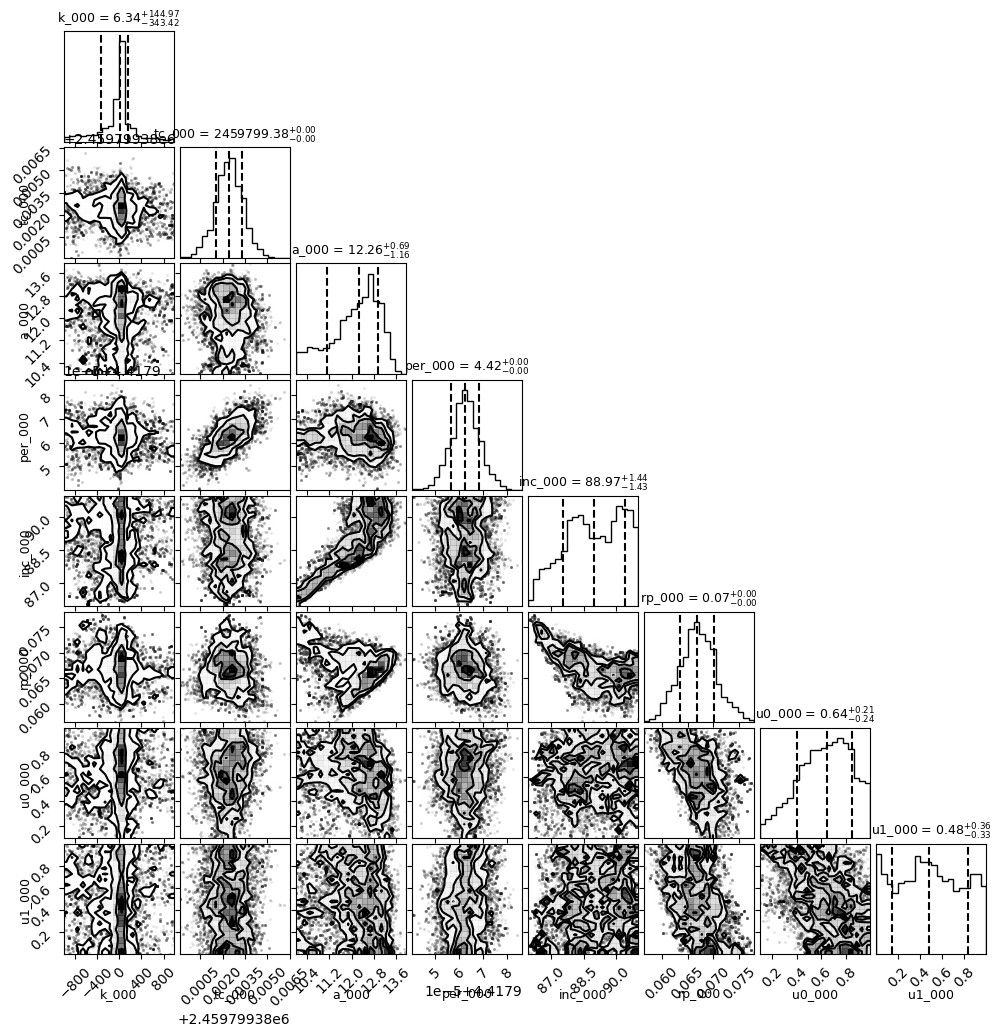

In [10]:
# Corner (pairs) plot of the posterior, built from the saved MCMC samples.
# We read the emcee HDF5 backend directly with emcee's own reader so the
# burn-in is discarded and the chain is flattened correctly.
import corner, emcee
import matplotlib.pyplot as plt

backend = emcee.backends.HDFBackend("outputs/TOI-3568_transit_samples.h5", read_only=True)
flat_samples = backend.get_chain(discard=300, flat=True)
labels = list(posterior["labels"])
print("samples for corner plot:", flat_samples.shape, "| labels:", labels)

fig = corner.corner(flat_samples, labels=labels,
                    quantiles=[0.16, 0.5, 0.84], show_titles=True,
                    title_kwargs={"fontsize": 9}, label_kwargs={"fontsize": 9})
fig.set_size_inches(10, 10)
plt.show()